# Tutorial for Training/Deploying the Physical CartPole Demo

This notebook follows the demo-hls4ml-25 README (Steps 1–7)

> Use the navigation links below to jump around quickly.


## Navigation
- [Step 1 — Environment Setup](#step-1--environment-setup)
- [Step 2 — Training Neural Network Controller](#step-2--training-neural-network-controller)
<!-- - [Step 3 — CartPole Simulator (GUI)](#step-3--cartpole-simulator-gui)
- [Step 4 — hls4ml Conversion](#step-4--conversion-of-neural-network-controller-using-hls4ml)
- [Step 5 — Testing on PC / Software Control (Local Only)](#step-5--testing-model-on-pc--running-model-via-pcsoftware-to-control-cartpole)
- [Step 6 — Implementation (Vivado/Vitis)](#step-6--implementation)
- [Step 7 — SD Card + FPGA Boot](#step-7--load-image-on-sd-card-and-onto-fpga) -->


## Step 0 — Notebook prerequisites 

- Please make sure you have Conda installed
    - Refer to [this article](https://docs.conda.io/projects/conda/en/latest/user-guide/install/index.html) for instructions on setting it up
- Ensure you have access to these programs
    - Vivado 2020.1 
    - Vitis 2020.1


## Step 1 — Environment Setup

### Conda environment
- In your terminal do these
```bash
conda create -n physical_cartpole python=3.9
conda activate physical_cartpole
```
### Install Packages
- These are just the necessary packages for training, we will install the GUI/Simulation packages later
<!-- these are the gui packages: # These need PyQt6 which I dont have rn (for the GUI)
## -e ./Driver/CartPoleSimulation/SI_Toolkit/
## %pip install watchdog pydot graphviz PyQt6 -->
**Lab server note:** if your environment is pre-configured, you can skip this step.


In [17]:
%pip install -r requirements.txt 
%pip install gitpython

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Step 2 — Training Neural Network Controller

### Dataset location
- The Seed dataset is initially located at: `./Experiment-1` in the root directory which contains:
    - recorded trajectories (CSV)
    - a known good model configuration

### 2.1 Choose experiment + model name

- `CARTPOLE_EXPERIMENT_NAME` (default: `Experiment-1`)
- `CARTPOLE_NET_NAME` (default shown below)


In [18]:
import os, shutil
from pathlib import Path

# Root of the git repository (assumes notebook is inside the repo)
REPO = Path.cwd().resolve()
WORKSPACE = REPO / "Driver" / "CartPoleSimulation" / "SI_Toolkit_ASF" / "Experiments"
SI_ASF = REPO / "Driver" / "CartPoleSimulation" / "SI_Toolkit_ASF"


# Experiment name (override via env var if provided)
EXPERIMENT_NAME = os.environ.get("CARTPOLE_EXPERIMENT_NAME", "Experiment-1")

# Neural network model name to use
NET_NAME = os.environ.get("CARTPOLE_NET_NAME", "Dense-7IN-32H1-32H2-1OUT-0")

# Path to seed (template) experiment shipped with the repo
SEED_EXPERIMENT = REPO / "Experiment-1"

# Path to active experiment workspace used by SI_Toolkit
ACTIVE_EXPERIMENT = WORKSPACE / EXPERIMENT_NAME

# Echo resolved paths and selected model for verification
print("SEED_EXPERIMENT:", SEED_EXPERIMENT)
print("ACTIVE_EXPERIMENT:", ACTIVE_EXPERIMENT)
print("NET_NAME:", NET_NAME)

SEED_EXPERIMENT: /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Experiment-1
ACTIVE_EXPERIMENT: /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1
NET_NAME: Dense-7IN-32H1-32H2-1OUT-0


### 2.2 Move/copy seed experiment into the SI_Toolkit experiments folder

This shell scripts effectively ensure the experiment lives under `SI_Toolkit_ASF/Experiments/`.
We do a safe copy **only if missing**, to avoid overwriting trained artifacts.


In [19]:
import shutil

if not ACTIVE_EXPERIMENT.exists():
    shutil.copytree(SEED_EXPERIMENT, ACTIVE_EXPERIMENT)
    print("Copied ./Experiment-1 →", ACTIVE_EXPERIMENT)
else:
    print("Active experiment already exists: not overwriting")


Active experiment already exists: not overwriting


Now there are **two paths**:

### Path A: Use precomputed model
- Uses a pre-trained model from the seed folder `../Experiment-1/Models`
- Skip to the Simulation (Step 3) 

### Path B: Train the neural network
- Follow the next steps

### 2.3 Training Configuration (config_training.yml)

Run this cell to see the current training configurations in:
`Driver/CartPoleSimulation/SI_Toolkit_ASF/config_training.yml`

In [20]:
import yaml
from pprint import pprint

with open("../physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/config_training.yml", "r") as f:
    cfg = yaml.safe_load(f)

pprint(cfg)

{'CONFIG_SERIES_MODIFICATION': {'MODE': 'train_for_random_vertical_angle_shift',
                                'NOISE_LEVEL': {'FEATURES': 0.1}},
 'FILTERS': None,
 'PRUNING': {'ACTIVATED': False,
             'PRUNING_PARAMS': {'PRUNING_SCHEDULE': 'CONSTANT_SPARSITY'},
             'PRUNING_SCHEDULES': {'CONSTANT_SPARSITY': {'begin_step_in_epochs': 1.0,
                                                         'end_step_in_training_fraction': 1.0,
                                                         'frequency_per_epoch': 100.0,
                                                         'target_sparsity': 0.75,
                                                         'target_sparsity_last_layer': 0.0},
                                   'POLYNOMIAL_DECAY': {'begin_step_in_epochs': 1.0,
                                                        'end_step_in_training_fraction': 0.8,
                                                        'final_sparsity': 0.75,
                         

Below is an **optional** cell that updates the yamls experiment path if you changed it, leaving your hyperparameters intact.

In [21]:
import yaml

cfg_path = SI_ASF / "config_training.yml"
cfg = yaml.safe_load(cfg_path.read_text())

def set_experiment_path(cfg_obj, new_path: str) -> bool:
    if isinstance(cfg_obj, dict):
        if "paths" in cfg_obj and isinstance(cfg_obj["paths"], dict) and "path_to_experiment" in cfg_obj["paths"]:
            cfg_obj["paths"]["path_to_experiment"] = new_path
            return True
        if "PATH_TO_EXPERIMENT" in cfg_obj:
            cfg_obj["PATH_TO_EXPERIMENT"] = new_path
            return True
    return False

ok = set_experiment_path(cfg, str(ACTIVE_EXPERIMENT))
if ok:
    cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False))
    print("Updated config_training.yml to use:", ACTIVE_EXPERIMENT)
else:
    print("Could not locate experiment path key; set it manually to:", ACTIVE_EXPERIMENT)

Updated config_training.yml to use: /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1


### 2.4 Data normalization

Neural networks train much more reliably when each feature is on a comparable numeric scale.

In this project, **normalization statistics are computed from the `Train/` CSVs** inside the active experiment folder.  
Those statistics are saved to `NormalizationInfo/` and then reused consistently for:

- training (inputs/targets are normalized the same way every run)
- simulation inference (the controller sees the same scaling)
- FPGA/HLS deployment (the firmware uses the same vectors)

The function that does this is `SI_Toolkit.load_and_normalize.calculate_normalization_info(...)`.


In [22]:
# Make sure imports resolve: SI_Toolkit lives under Driver/CartPoleSimulation/SI_Toolkit/src
import sys
from pathlib import Path

SIM = REPO / "Driver" / "CartPoleSimulation"

# Prepend SI_Toolkit/src so `import SI_Toolkit...` works even without pip install -e
si_src = SIM / "SI_Toolkit" / "src"
if str(si_src) not in sys.path:
    sys.path.insert(0, str(si_src))

# Also prepend the simulator root so `SI_Toolkit_ASF` resolves cleanly when running from the notebook
if str(SIM) not in sys.path:
    sys.path.insert(0, str(SIM))

print("SIM =", SIM)
print("SI_Toolkit src =", si_src)


SIM = /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation
SI_Toolkit src = /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit/src


In [23]:
# Load the training configuration
import yaml

cfg_path = SI_ASF / "config_training.yml"
cfg = yaml.safe_load(cfg_path.read_text())

# The two path keys
print("PATH_TO_EXPERIMENT_FOLDERS =", cfg["paths"]["PATH_TO_EXPERIMENT_FOLDERS"])
print("path_to_experiment         =", cfg["paths"]["path_to_experiment"])
print("DATA_FOLDER                =", cfg["paths"]["DATA_FOLDER"])

train_dir = Path(cfg["paths"]["PATH_TO_EXPERIMENT_FOLDERS"]) / cfg["paths"]["path_to_experiment"] / cfg["paths"]["DATA_FOLDER"] / "Train"
print("\nTrain directory (resolved):", train_dir.resolve())


PATH_TO_EXPERIMENT_FOLDERS = ./SI_Toolkit_ASF/Experiments/
path_to_experiment         = /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1
DATA_FOLDER                = Recordings

Train directory (resolved): /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/Recordings/Train


In [24]:
# Enumerate the CSVs used for normalization
import glob

train_csvs = sorted(glob.glob(str(train_dir / "*.csv")))
print(f"Found {len(train_csvs)} training CSV files.")
for p in train_csvs[:10]:
    print(" -", p)
if len(train_csvs) > 10:
    print(f" ... ({len(train_csvs)-10} more)")


Found 40 training CSV files.
 - /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/Recordings/Train/Experiment-1.csv
 - /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/Recordings/Train/Experiment-10.csv
 - /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/Recordings/Train/Experiment-11.csv
 - /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/Recordings/Train/Experiment-12.csv
 - /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/Recordings/Train/Experiment-13.csv
 - /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physi

#### 2.4.1 Compute normalization statistics + write `NormalizationInfo/NI_*.csv`

By default the function:
- concatenates all Train CSVs into one DataFrame
- drops a `time` column (if present)
- computes per-feature **mean/std/min/max**
- optionally applies a **user correction hook** from `SI_Toolkit_ASF/ToolkitCustomization/...`
- writes a timestamped `NI_YYYY-MM-DD_HH-MM-SS.csv`
- optionally saves histogram PNGs per feature



# Datafiles used to calculate normalization:
    - /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/Recordings/Train/Experiment-1.csv
    - /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/Recordings/Train/Experiment-10.csv
    - /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/Recordings/Train/Experiment-11.csv
    - /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/Recordings/Train/Experiment-12.csv
    - /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/Recordings/Train/Experiment-13.csv
    - /mnt/raid5/asic/projects/NU/s

100%|██████████| 40/40 [00:02<00:00, 14.10it/s]


User defined normalization correction not applied. 
The needed function not found in SI_Toolkit_ASF.user_defined_normalization_correction.py
Fallback: No normalization correction applied.
Wrote normalization CSV: /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/NormalizationInfo/NI_2026-01-31_12-46-03.csv


,L,Q_applied,Q_calculated,Q_update_time,angle,angleD,angleDD,angle_cos,angle_sin,position,positionD,positionDD,target_equilibrium,target_position,u
mean,0.1975,0.00042,0.00117,0.03367,0.01497,-0.02150,0.00489,0.29482,-0.00048,0.00213,0.00028,-0.00085,0.61113,0.00294,0.00110
std,0.0000,0.84009,0.67524,0.00239,1.63075,3.63327,27.84407,0.84830,0.43985,0.08979,0.31464,6.91598,0.79153,0.09415,2.20105
max,0.1975,3.45131,1.00000,0.07250,3.14159,21.20846,149.43159,1.00000,1.00000,0.18849,1.29035,38.14955,1.00000,0.15840,9.04242
min,0.1975,-3.22717,-1.00000,0.02201,-3.14159,-22.31282,-146.51372,-1.00000,-1.00000,-0.19525,-1.14834,-38.20432,-1.00000,-0.15840,-8.45518


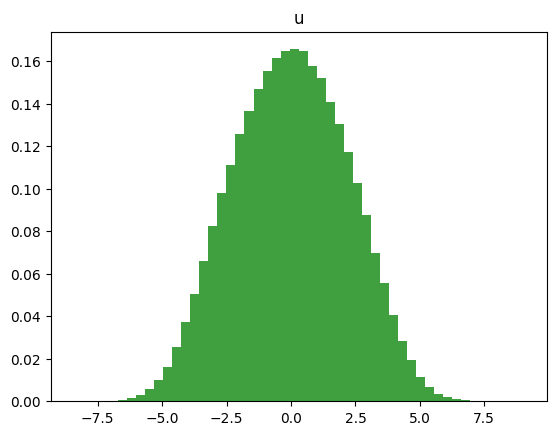

In [25]:
# Run the normalization (preprocessing) step
from SI_Toolkit.load_and_normalize import calculate_normalization_info

# Keep histograms ON for now, optionally turn OFF for speed in automated runs
df_norm_info, norm_csv_path = calculate_normalization_info(
    config=cfg,
    plot_histograms=True,
    user_correction=True,
)

print("Wrote normalization CSV:", norm_csv_path)
display(df_norm_info)


#### 2.4.2 How to read `df_norm_info`

`df_norm_info` is indexed by the statistic (`mean`, `std`, `min`, `max`).  
Each column is a feature from your training CSVs (excluding `time`).

Typical z-score normalization uses:

- **normalize**:  \(x_{norm} = (x - \mu) / \sigma\)
- **denormalize**: \(x = x_{norm} \cdot \sigma + \mu\)

The exact columns used as inputs/targets are determined by your training config and the model wrapper,
but the statistics come from the raw CSV columns.


#### 2.4.3 Where the histograms went

If `plot_histograms=True`, the function saves one histogram per feature to:

`.../NormalizationInfo/histograms/<feature>.png`

This is a quick sanity check for:
- heavy tails / outliers (might warrant clipping or a user correction)
- nearly-constant channels (std ~ 0)
- unexpected units / scaling


In [26]:
# Show a couple histogram images (if they were generated)
from pathlib import Path

hist_dir = Path(norm_csv_path).parent / "histograms"
print("Histogram dir:", hist_dir)

if hist_dir.exists():
    pngs = sorted(hist_dir.glob("*.png"))
    print("Found", len(pngs), "histograms.")
else:
    print("No histograms folder found (plot_histograms may be False).")


Histogram dir: /mnt/raid5/asic/projects/NU/sandboxes/jacobj/cartpole_demo/physical-cartpole/Driver/CartPoleSimulation/SI_Toolkit_ASF/Experiments/Experiment-1/NormalizationInfo/histograms
Found 15 histograms.


### 2.5 Train the neural network